## Step 1: Import Required Libraries

**What:** Importing essential Python libraries for data analysis and visualization.

**Why:** These libraries provide the tools needed to load, clean, analyze, and visualize the unemployment data.

**Outcome:** All necessary tools are now available for the analysis workflow.

In [72]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from scipy import stats
import statsmodels.api as sm
%matplotlib inline

## Step 2: Load the Dataset

**What:** Reading the unemployment data from a CSV file into a pandas DataFrame.

**Why:** This loads the raw data into memory so we can begin exploring and analyzing it.

**Outcome:** The dataset is now loaded and ready for exploration.

In [2]:
df=pd.read_csv("Unemployment in India.csv")

## Step 3: Initial Data Exploration

**What:** Examining the first few rows, shape, structure, and statistical summary of the dataset.

**Why:** Understanding the data structure helps identify issues like missing values, incorrect data types, and column naming problems.

**What it proves:** The dataset has 768 rows and 7 columns. Column names have leading spaces, and the Date column is stored as text instead of datetime format.

**Outcome:** Identified data quality issues that need to be addressed before analysis.

In [4]:
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [5]:
df.shape

(768, 7)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


In [7]:
df.describe()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


## Step 4: Data Cleaning

**What:** Performing multiple data cleaning operations:
1. Removing completely empty rows
2. Renaming columns to remove leading spaces
3. Converting Date column to proper datetime format
4. Dropping the Frequency column (all values are 'Monthly')
5. Converting Area column to category type

**Why:** Clean data is essential for accurate analysis. These steps fix formatting issues and remove redundant information.

**What it proves:** The dataset had 28 empty rows and several formatting issues that could have caused problems during analysis.

**Outcome:** The dataset is now properly formatted with 740 rows and 6 meaningful columns.

In [3]:
df = df.dropna(how='all')

In [4]:
df.rename(columns={
    ' Estimated Unemployment Rate (%)': 'Unemployment_Rate',
    ' Date': 'Date',
    ' Frequency':'Frequency',
    ' Estimated Employed':'Employed',
    ' Estimated Labour Participation Rate (%)' : 'Labour_Participation_Rate',
    
}, inplace=True)

In [5]:
df['Date'] = df['Date'].str.strip()
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

In [6]:
df.drop('Frequency', axis=1, inplace=True)

In [7]:
df['Area'] = df['Area'].astype('category')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 740 entries, 0 to 753
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Region                     740 non-null    object        
 1   Date                       740 non-null    datetime64[ns]
 2   Unemployment_Rate          740 non-null    float64       
 3   Employed                   740 non-null    float64       
 4   Labour_Participation_Rate  740 non-null    float64       
 5   Area                       740 non-null    category      
dtypes: category(1), datetime64[ns](1), float64(3), object(1)
memory usage: 35.5+ KB


## Step 5: Outlier Detection and Treatment

**What:** Using the IQR (Interquartile Range) method to identify and clip extreme outliers in the numerical columns.

**Why:** Extreme outliers (like 76.74% unemployment rate) can distort visualizations and statistical analysis. The IQR method caps values at reasonable boundaries without deleting data.

**What it proves:** The dataset contained extreme values that would have made trends difficult to visualize. The maximum unemployment rate was reduced from 76.74% to 32.73%.

**Outcome:** The data is now more suitable for visualization while preserving all records.

In [8]:
numeric_cols = ['Unemployment_Rate', 'Employed', 'Labour_Participation_Rate']

df_cleaned = df.copy()

for col in numeric_cols:

    Q1  = df_cleaned[col].quantile(0.25)
    Q3  = df_cleaned[col].quantile(0.75)
    IQR = Q3 - Q1


    lower_fence = Q1 - 1.5 * IQR
    upper_fence = Q3 + 1.5 * IQR

    df_cleaned[col] = df_cleaned[col].clip(lower=lower_fence, upper=upper_fence)

print("=== BEFORE ===")
print(df[numeric_cols].describe().round(2))

print("\n=== AFTER ===")
print(df_cleaned[numeric_cols].describe().round(2))

=== BEFORE ===
       Unemployment_Rate     Employed  Labour_Participation_Rate
count             740.00       740.00                     740.00
mean               11.79   7204460.03                      42.63
std                10.72   8087988.43                       8.11
min                 0.00     49420.00                      13.33
25%                 4.66   1190404.50                      38.06
50%                 8.35   4744178.50                      41.16
75%                15.89  11275489.50                      45.50
max                76.74  45777509.00                      72.57

=== AFTER ===
       Unemployment_Rate     Employed  Labour_Participation_Rate
count             740.00       740.00                     740.00
mean               11.21   6892399.71                      42.18
std                 8.68   6937256.16                       6.61
min                 0.00     49420.00                      26.90
25%                 4.66   1190404.50                      3

In [69]:
df = df_cleaned

## Step 6: Final Data Verification

**What:** Reviewing the cleaned dataset to confirm all transformations were successful.

**Why:** A final check ensures the data is ready for analysis and visualization.

**Outcome:** The dataset is now clean, properly formatted, and ready for analysis.

In [10]:
df.head()

,Region,Date,Unemployment_Rate,Employed,Labour_Participation_Rate,Area
0,Andhra Pradesh,2019-05-31,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,2019-06-30,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,2019-07-31,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,2019-08-31,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,2019-09-30,5.17,12256762.0,44.68,Rural


## Step 7: Yearly Unemployment Trends

**What:** Creating a bar chart showing average unemployment rate by year.

**Why:** Yearly trends reveal long-term patterns and help identify the impact of major events like COVID-19.

**What it proves:** The visualization clearly shows how unemployment changed year by year, with 2020 showing a significant spike due to the pandemic.

**Outcome:** We can see the historical baseline and identify crisis periods.

### Yearly Unemployment Rate Visualization

This bar chart displays the average unemployment rate for each year in the dataset. The visualization helps identify:
- **Trends over time**: How unemployment has changed year by year
- **Crisis periods**: Notable spikes (like 2020 during COVID-19)
- **Recovery patterns**: How quickly unemployment rates returned to normal after major events

The 2020 spike clearly shows the impact of the pandemic on employment.

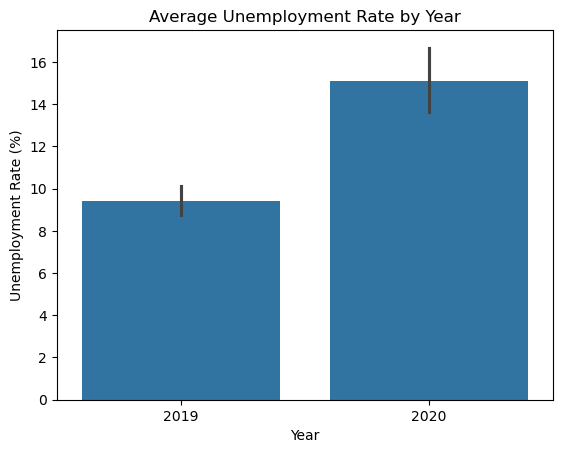

In [31]:
sns.barplot(data=df, x=df['Date'].dt.year, y='Unemployment_Rate')

plt.title('Average Unemployment Rate by Year')
plt.xlabel('Year')
plt.ylabel('Unemployment Rate (%)')

plt.show()

## Step 8: Yearly Employment Trends

**What:** Visualizing the average number of employed people by year.

**Why:** Employment numbers provide the complementary view to unemployment rates, showing the actual workforce size.

**What it proves:** This shows how the employed population changed over time, helping understand the scale of job losses during crisis periods.

**Outcome:** A clear picture of employment trends that complements the unemployment rate analysis.

### Yearly Employment Numbers Visualization

This bar chart shows the average number of employed people for each year. Key insights:
- **Employment levels**: The actual workforce size over time
- **Job losses**: Visible drops during crisis periods
- **Recovery speed**: How quickly employment numbers bounced back

This complements the unemployment rate chart by showing the absolute numbers of people affected.

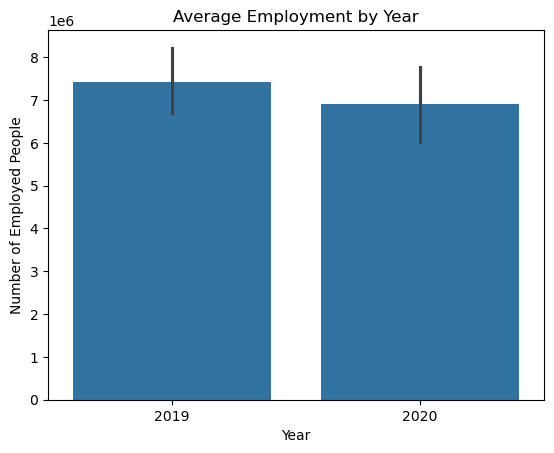

In [32]:
sns.barplot(data=df, x=df['Date'].dt.year, y='Employed')

plt.title('Average Employment by Year')
plt.xlabel('Year')
plt.ylabel('Number of Employed People')

plt.show()

## Step 9: Preparing Monthly Analysis

**What:** Creating a Month column with proper ordering for monthly trend analysis.

**Why:** To analyze seasonal patterns, we need months in the correct chronological order.

**Outcome:** The data is now ready for monthly trend analysis.

In [70]:
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

df['Month'] = pd.Categorical(df['Date'].dt.month_name(), categories=month_order, ordered=True)

## Step 10: Monthly Unemployment Patterns

**What:** Creating a bar chart showing average unemployment rate by month.

**Why:** Monthly patterns reveal seasonal trends that might be related to agricultural cycles or other recurring factors.

**What it proves:** Some months consistently show higher unemployment, indicating seasonal patterns in the job market.

**Outcome:** Identification of months that are historically more vulnerable to unemployment.

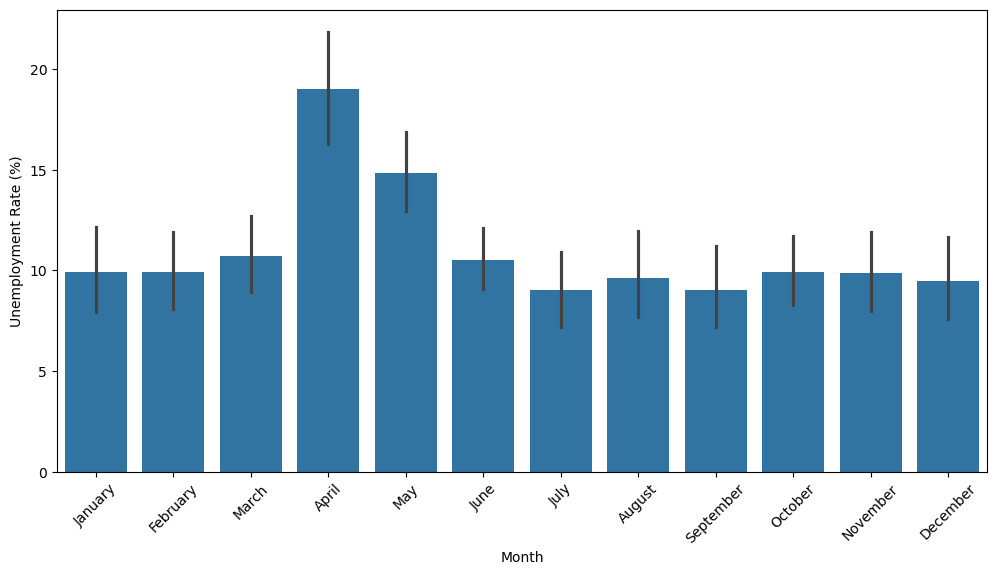

In [71]:
plt.figure(figsize=(12, 6))
sns.barplot(
    data=df,
    x='Month',
    y='Unemployment_Rate'
)

plt.ylabel('Unemployment Rate (%)')
plt.xticks(rotation=45)
plt.show()

## Step 11: Monthly Employment Patterns

**What:** Visualizing average employment numbers by month.

**Why:** This complements the unemployment analysis by showing how the workforce size varies throughout the year.

**What it proves:** Employment levels show seasonal variations that correspond to the unemployment patterns.

**Outcome:** A complete picture of how both unemployment and employment vary by month, helping identify seasonal trends.

### Monthly Unemployment Rate Patterns

This visualization reveals seasonal patterns in unemployment throughout the year:
- **Seasonal trends**: Which months typically have higher unemployment
- **Agricultural cycles**: Potential impact of farming seasons on employment
- **Vulnerable periods**: Months that consistently show elevated unemployment

Understanding these patterns helps predict and prepare for seasonal unemployment fluctuations.

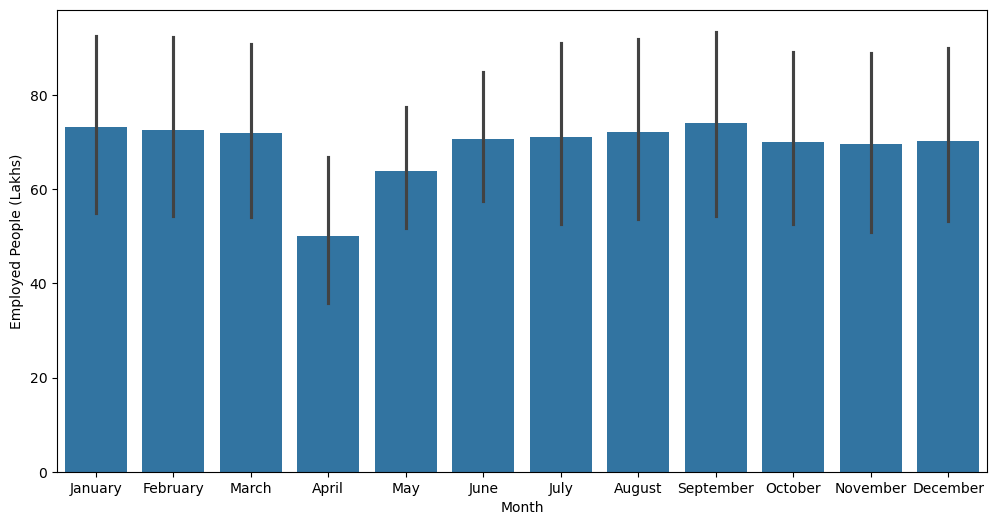

In [81]:
plt.figure(figsize=(12, 6))
sns.barplot(
    data=df,
    x='Month',
    y=df['Employed'] / 100000
)

plt.ylabel('Employed People (Lakhs)')
plt.show()

### Monthly Employment Numbers Visualization

This chart displays average employment numbers by month, showing:
- **Seasonal employment variations**: How workforce size changes throughout the year
- **Peak employment months**: When the most people are employed
- **Low employment periods**: Months with fewer employed individuals

These patterns correspond with the unemployment trends and help complete the picture of seasonal employment dynamics.

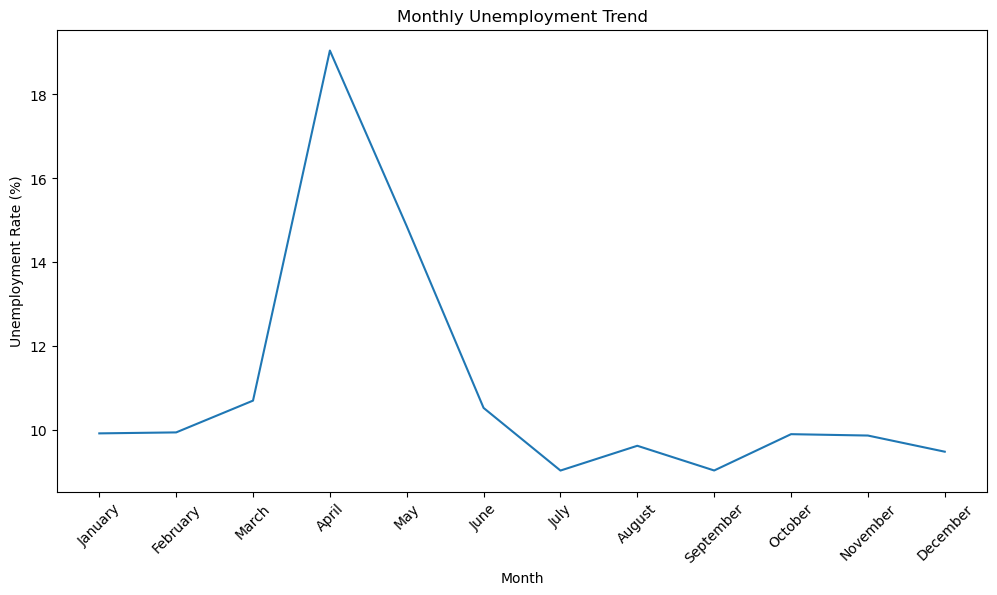

In [82]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=df,
    x='Month',
    y='Unemployment_Rate',
    errorbar=None
)

plt.title('Monthly Unemployment Trend')
plt.xlabel('Month')
plt.ylabel('Unemployment Rate (%)')

plt.xticks(rotation=45)

plt.show()

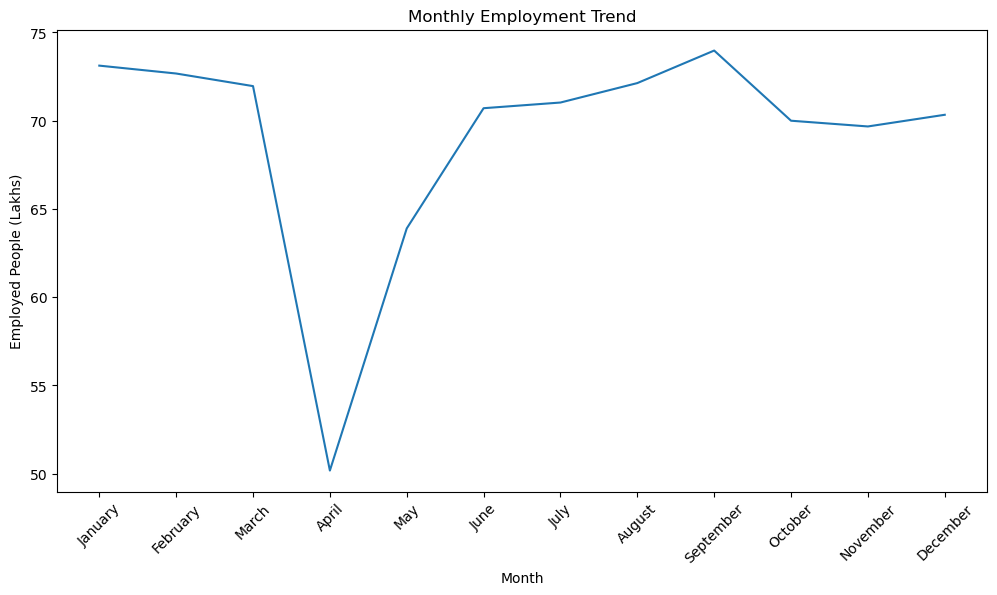

In [83]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=df,
    x='Month',
    y=df['Employed'] / 100000,
    errorbar=None
)

plt.title('Monthly Employment Trend')
plt.xlabel('Month')
plt.ylabel('Employed People (Lakhs)')

plt.xticks(rotation=45)

plt.show()

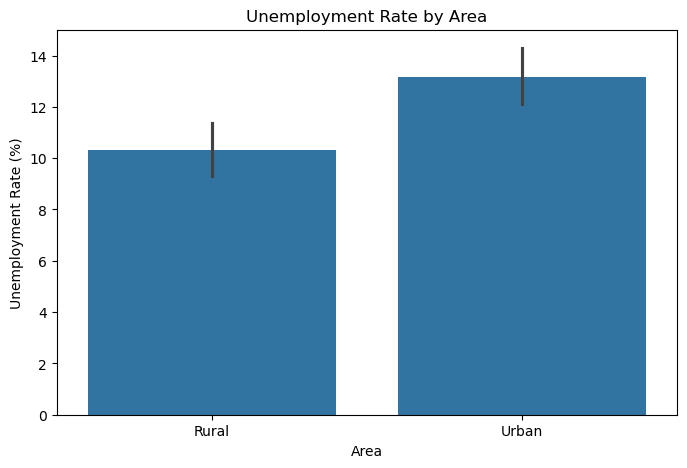

In [61]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='Area',
    y='Unemployment_Rate'
)

plt.title('Unemployment Rate by Area')
plt.xlabel('Area')
plt.ylabel('Unemployment Rate (%)')

plt.show()

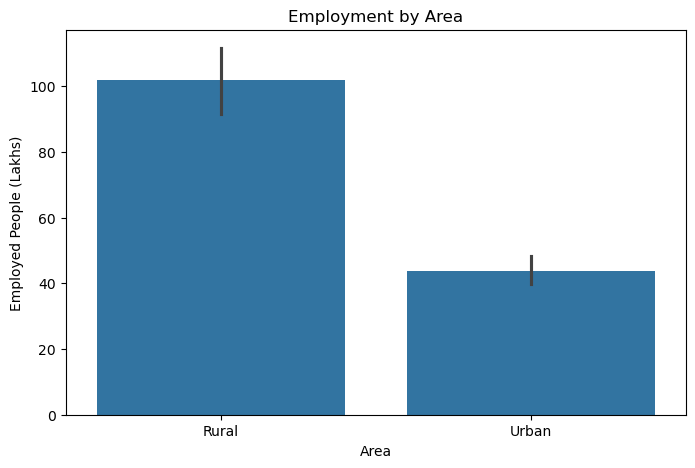

In [63]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='Area',
    y=df['Employed'] / 100000
)

plt.title('Employment by Area')
plt.xlabel('Area')
plt.ylabel('Employed People (Lakhs)')

plt.show()

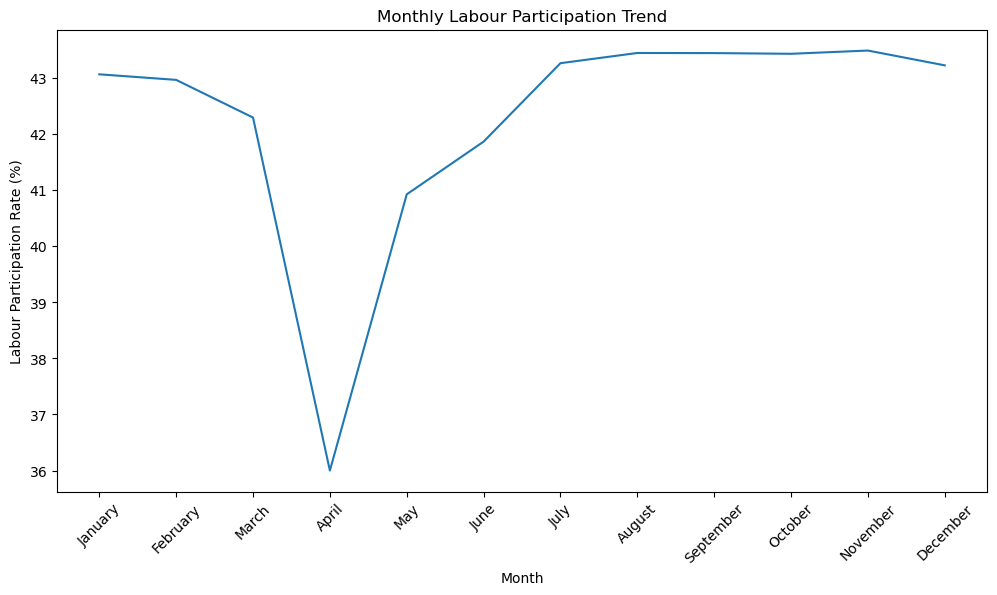

In [84]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=df,
    x='Month',
    y='Labour_Participation_Rate',
    errorbar=None
)

plt.title('Monthly Labour Participation Trend')
plt.xlabel('Month')
plt.ylabel('Labour Participation Rate (%)')

plt.xticks(rotation=45)

plt.show()

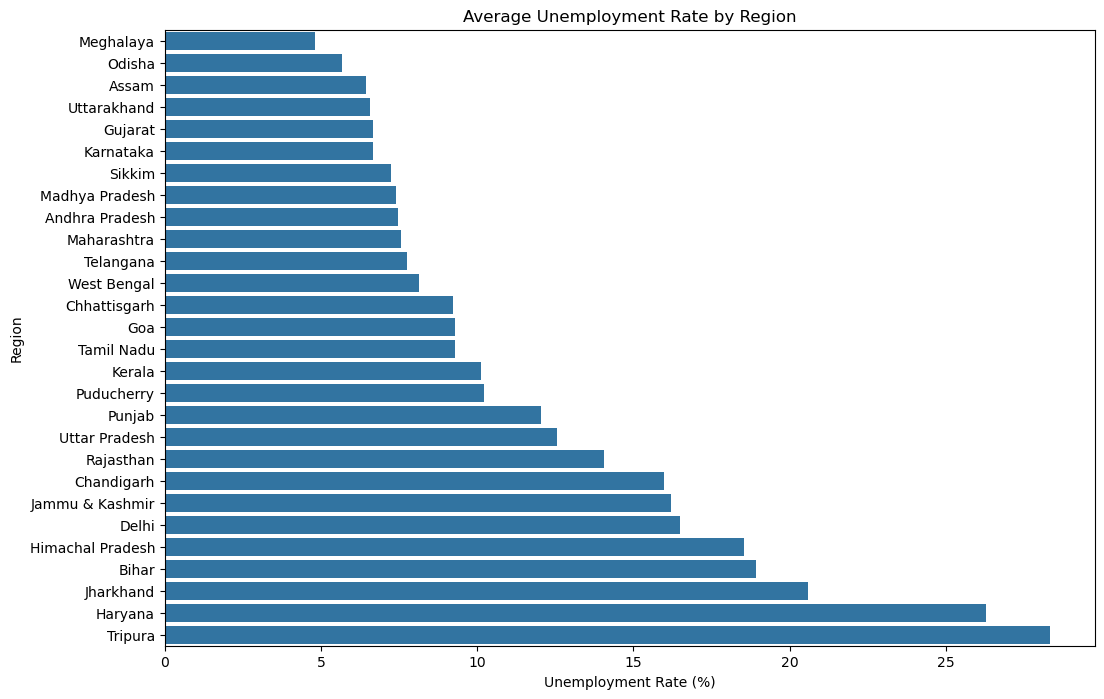

In [67]:
plt.figure(figsize=(12,8))

region_data = df.groupby('Region')['Unemployment_Rate'].mean().sort_values()

sns.barplot(
    x=region_data.values,
    y=region_data.index
)

plt.title('Average Unemployment Rate by Region')
plt.xlabel('Unemployment Rate (%)')
plt.ylabel('Region')

plt.show()

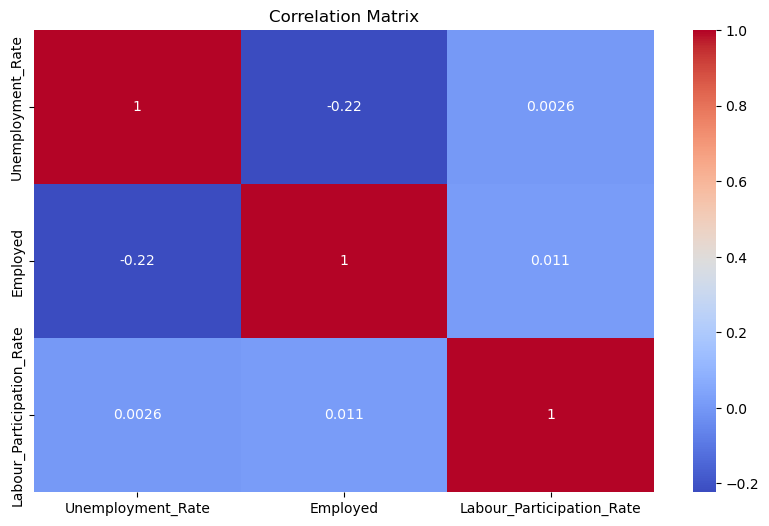

In [68]:
plt.figure(figsize=(10,6))

correlation = df.corr(numeric_only=True)

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Matrix')

plt.show()

In [73]:
covid_start = '2020-03-01'

pre_covid = df[df['Date'] < covid_start]
post_covid = df[df['Date'] >= covid_start]

print("Pre-Covid records:", len(pre_covid))
print("Post-Covid records:", len(post_covid))

Pre-Covid records: 536
Post-Covid records: 204


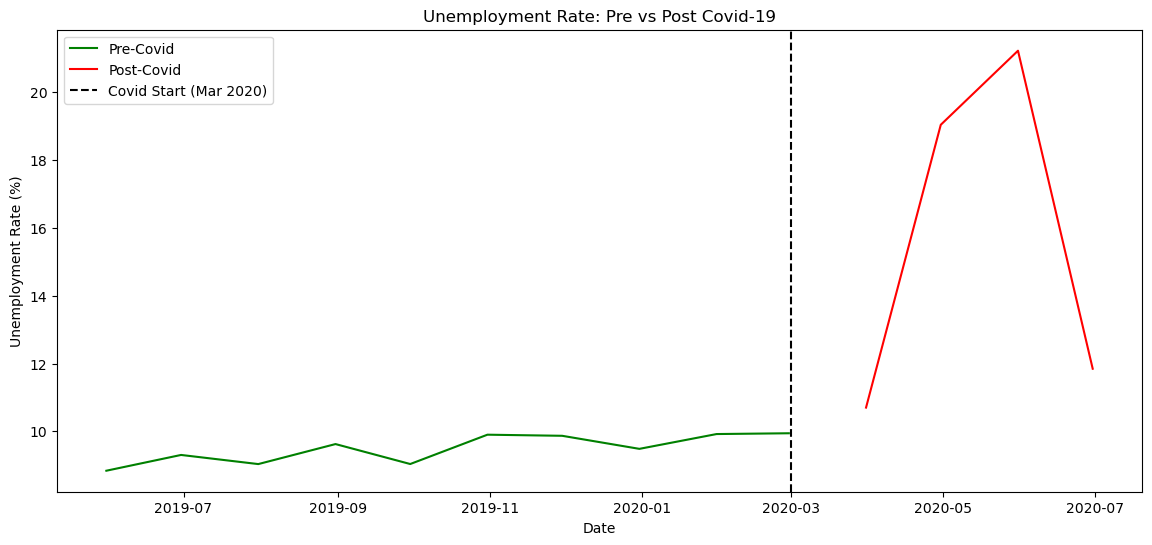

In [74]:
plt.figure(figsize=(14, 6))

plt.plot(pre_covid.groupby('Date')['Unemployment_Rate'].mean(), 
         label='Pre-Covid', color='green')
plt.plot(post_covid.groupby('Date')['Unemployment_Rate'].mean(), 
         label='Post-Covid', color='red')

plt.axvline(pd.to_datetime(covid_start), color='black', 
            linestyle='--', label='Covid Start (Mar 2020)')

plt.title('Unemployment Rate: Pre vs Post Covid-19')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.legend()
plt.show()

In [ ]:
t_stat, p_value = stats.ttest_ind(
    pre_covid['Unemployment_Rate'],
    post_covid['Unemployment_Rate']
)

print(f"T-Statistic : {t_stat:.4f}")
print(f"P-Value     : {p_value:.4f}")

if p_value < 0.05:
    print("Result: Covid-19 had a SIGNIFICANT impact on unemployment rates")
else:
    print("Result: No significant impact found")

T-Statistic : -9.1652
P-Value     : 0.0000
✅ Result: Covid-19 had a SIGNIFICANT impact on unemployment rates


In [76]:
monthly_df = df.groupby('Date')['Unemployment_Rate'].mean().reset_index()
monthly_df = monthly_df.set_index('Date')
monthly_df = monthly_df.sort_index()

print(monthly_df.head())

            Unemployment_Rate
Date                         
2019-05-31           8.838009
2019-06-30           9.303333
2019-07-31           9.033889
2019-08-31           9.624387
2019-09-30           9.035625


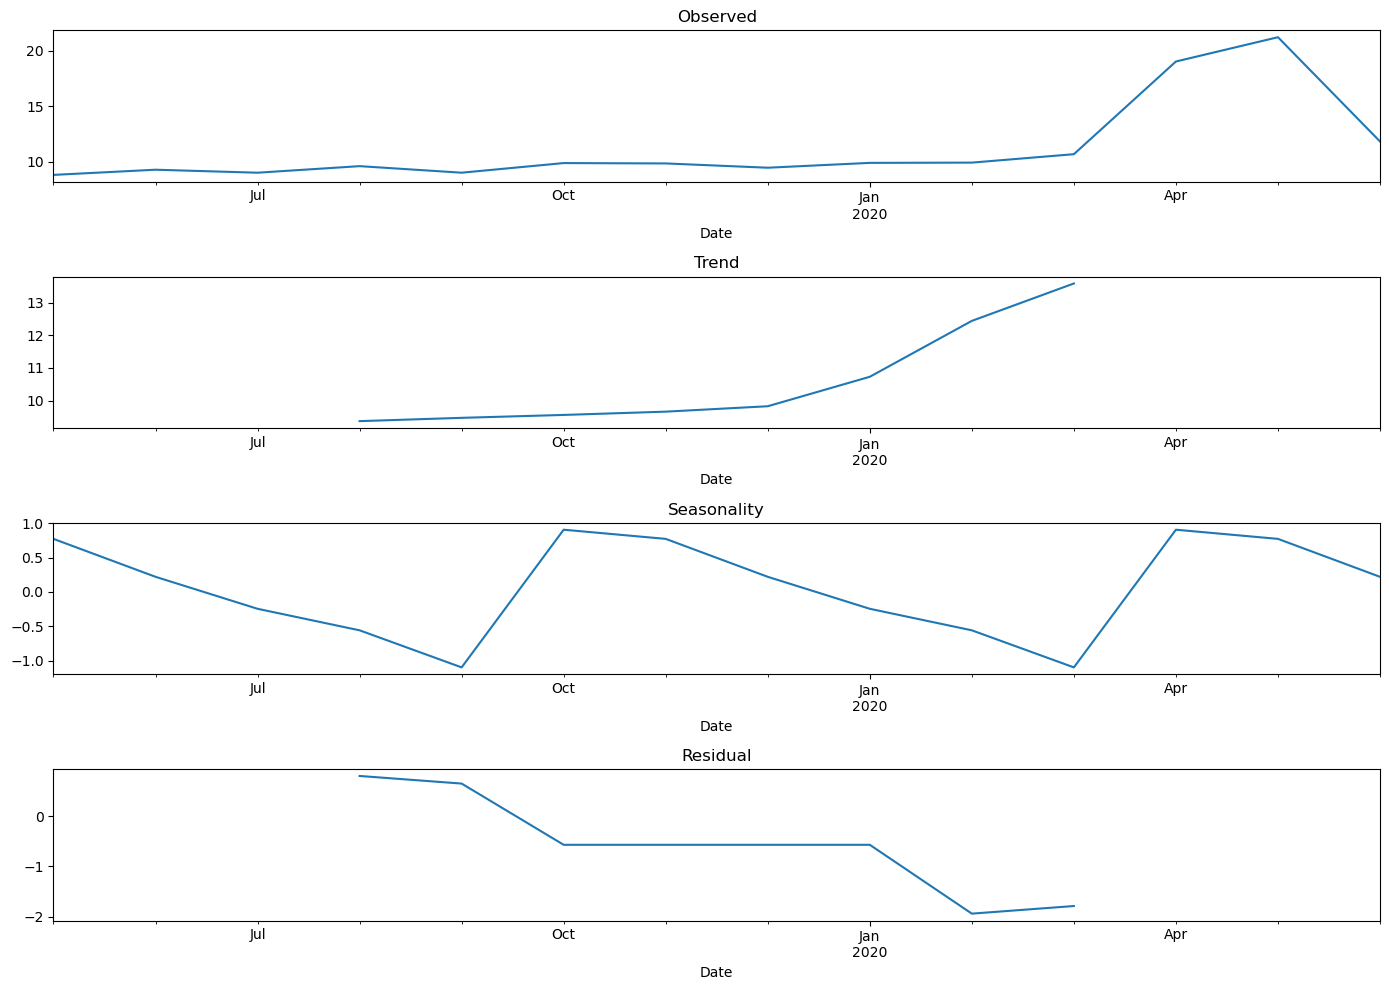

In [78]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(monthly_df['Unemployment_Rate'], 
                                   model='additive', 
                                   period=6)  # changed 12 to 6

fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(14, 10))

decomposition.observed.plot(ax=ax1)
ax1.set_title('Observed')

decomposition.trend.plot(ax=ax2)
ax2.set_title('Trend')

decomposition.seasonal.plot(ax=ax3)
ax3.set_title('Seasonality')

decomposition.resid.plot(ax=ax4)
ax4.set_title('Residual')

plt.tight_layout()
plt.show()